# Config

In [4]:
!git config --global --add safe.directory /tmp/Repository/VRID_language_proyect

In [5]:
import os

# Ruta a la que quieres mover el path
nueva_ruta = "/tmp/Repository/VRID_language_proyect/BERT"

# Cambiar el directorio actual
os.chdir(nueva_ruta)

# Confirmar que cambió
print("Directorio actual:", os.getcwd())

Directorio actual: /tmp/Repository/VRID_language_proyect/BERT


In [6]:
import pandas as pd
import os
from preprocess.preprocess import clean_text, check_deleted_expressions
from preprocess.translate import translator, gen_text_for_embedding, final_clean, detect_language
import time
import json
import numpy as np

# 1) Preprocesamiento de los datos


In [5]:
# 1) Cargar datos
path = "/tmp/data"
path_analytics = "/tmp/analytics"
filePATH = os.path.join(path, "data_concatenada.xlsx")
df = pd.read_excel(filePATH,
                   usecols=["Código VRID", "Título", "Resumen", "Keywords", "Interdisciplinario", "Transdisciplinario", "Facultad del Proyecto",
                            "Depto Persona"]) \
       .fillna("")

# 2) Guardar qué secuencias de palabras del resumen serán eliminadas al aplicar get_expressions_to_delete()
list_texts = df["Resumen"].to_list()
df_deleted = check_deleted_expressions(list_texts)

# 3) Preprocesar los datos
#Columnas que se van a preprocesar
#Nombre fila seleccionada:Columna que se creará para guardar resultado
cols = {
    "Título": "Titulo_trad",
    "Resumen": "Resumen_trad",
    "Keywords": "keywords_trad",
    "Facultad del Proyecto": "Facultad_del_Proyecto_trad",
}
#Preprocesamiento de datos
df[list(cols.values())] = df[list(cols.keys())].applymap(clean_text)
savepath=os.path.join(path, "data_clean.xlsx")
#df.to_excel(savepath, index=False)

# 2) Traducción del texto

In [6]:
#Crear columna de registro de idioma: 
# True: Texto en español, False: Texto en inglés
df["Español"]=detect_language(df["Resumen_trad"])

In [ ]:
from transformers import MarianMTModel, MarianTokenizer

#1. Cargar modelo de traducción
model_name = "Helsinki-NLP/opus-mt-es-en"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)
trans = translator(model, tokenizer)

#Columnas que se van a traducir
#Nombre fila seleccionada:Columna que se creará para guardar resultado
cols = {
    "Titulo_trad": "Titulo_trad",
    "Resumen_trad": "Resumen_trad",
    "keywords_trad": "keywords_trad",
    "Facultad_del_Proyecto_trad": "Facultad_del_Proyecto_trad",
    "Depto_Persona_trad": "Depto_Persona_trad",
}

#2. Traducción de columnas
#####Estoy trabajando en mejorar esta parte para que sea más rápida con paralelización por batches
start = time.time()
for src, dst in cols.items():
    df[dst] = trans.translate_parallel(df[src].to_list(), batch_size=8)
end = time.time()


#3.Guardado de resultados
savepath=os.path.join(path, "data_translated.xlsx")
#df.to_excel(savepath, index=False)

print(f"Tiempo total de traducción: {end - start:.2f} segundos")

In [ ]:
#3. Selección de columnas que se utilizarán en clasificador y concatenación
# Última limpieza antes de generar concatenación
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad", "Facultad_del_Proyecto_trad", "Depto_Persona_trad"]
for col in cols:
    df[col] = df[col].apply(final_clean)

#  Selección de columnas para embedding.
cols = ["Titulo_trad", "keywords_trad", "Resumen_trad"]
element_names = ["title", "keywords", "abstract"]
df = gen_text_for_embedding(df, cols, element_names)

# Guardado de resultados
savepath=os.path.join(path, "data_translated_concat.xlsx")
#df.to_excel(savepath, index=False)
savepath=os.path.join(path, "data_translated_concat.csv")
#df.to_csv(savepath, index=False, encoding="utf-8-sig")

df.head()

,Código VRID,Interdisciplinario,Transdisciplinario,Título,Keywords,Resumen,Facultad del Proyecto,Depto Persona,Titulo_trad,Resumen_trad,keywords_trad,Facultad_del_Proyecto_trad,Depto_Persona_trad,Español,text_for_embedding_translated
0,2023-059,NO,,PROGRAMA DE INVESTIGACIÓN EN ECONOMÍA DE RECUR...,"ECONOMÍA AMBIENTAL, ECONOMÍA DE RECURSOS NATUR...",NENRE EFD-CHILE EN UN PROGRAMA DE INVESTIGACIÓ...,CAMPUS CHILLÁN,"DEPARTAMENTO DE ECONOMÍA, DIRECCIÓN DE DESARRO...",research programme on the economics of natural...,in a research program that seeks to contribute...,"environmental economy, economy of natural reso...",campus chillán,"department of economics, development and innov...",True,title: research programme on the economics of ...
1,40044450,SI,,DISTRITO INNOVACIÓN ÑUBLE: HERRAMIENTA DE DESA...,"INNOVACIÓN, INVESTIGACIÓN Y DESARROLLO, AGRICU...",EL DISTRITO DE INNOVACIÓN DE ÑUBLE ES UN PROYE...,FACULTAD DE CIENCIAS VETERINARIAS,"DEPARTAMENTO DE CIENCIA ANIMAL, DEPARTAMENTO D...",innovation district: regional development tool...,the district of innovation of ñuble is a proje...,"innovation, research and development, precisio...",faculty of veterinary sciences,"department of animal science, department of pl...",True,title: innovation district: regional developme...
2,#2024-5501,NO,,MULTI-PHYSICS AND MULTI-SCALE INTEGRATED STUDI...,,,FACULTAD DE CIENCIAS FÍSICAS Y MATEMÁTICAS,DEPARTAMENTO DE ASTRONOMÍA,multi-physics and multi-scale integrated studi...,,,faculty of physical sciences and mathematics,department of astronomy,False,title: multi-physics and multi-scale integrate...
3,+COMUNIDAD 3,NO,,ESTUDIO DE IMPLEMENTACIÓN DE LOS PLANES DE DES...,"LIDERAZGO ESCOLAR, DESARROLLO PROFESIONAL DOCE...","EL CENTRO +COMUNIDAD, CENTRO DE LIDERAZGO EDUC...",FACULTAD DE EDUCACIÓN,"DECANATO DE EDUCACIÓN, DEPARTAMENTO DE CIENCIA...",study of the implementation of professional te...,"the center +community, center of educational l...","school leadership, professional teacher develo...",faculty of education,"decanate of education, department of education...",True,title: study of the implementation of professi...
4,+COMUNIDAD2,NO,,DISEÑO Y EJECUCIÓN DE UN SISTEMA DE LÍNEA BASE...,"LIDERAZGO ESCOLAR, REDES DE COLABORACIÓN, CAPA...","EL CENTRO +COMUNIDAD, CENTRO DE LIDERAZGO EDUC...",ESCUELA DE EDUCACIÓN,DEPTO. TEORÍA POLITICA Y FUND.DE LA EDUC.,design and implementation of a baseline system...,"the center + community, center of educational ...","school leadership, collaborative networks, tea...",education school,department of political and fund theory of edu...,True,title: design and implementation of a baseline...


# 3) Split dataset

In [7]:
def to_serializable(obj):
    if hasattr(obj, "tolist"):
        return obj.tolist()
    return obj

In [9]:
path = "/tmp/desafios/data"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

conditions = [(df["Desafío País"] == 1) | (df["Desafío País"] == "1,2,3"),
              (df["Desafío País"] == 2) | (df["Desafío País"] == "1,2,3") | (df["Desafío País"] == "2.4"),
              (df["Desafío País"] == 3) | (df["Desafío País"] == "1,2,3"),
              (df["Desafío País"] == 4) | (df["Desafío País"] == "2.4")]
condition_name = ["1", "2", "3", "4"]  


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
import json



for idx, condition in enumerate(conditions):
    df["desafio_labels"] = np.where(
        condition, 
        1, 
        0
    )
    df["desafio_labels"].value_counts()

    # Convertir a arrays
    ids = df["Código VRID"].to_numpy()
    labels = df["desafio_labels"].to_numpy()

    # Train/Test split (ids y labels en paralelo)
    idx_train, idx_test, y_train, y_test = train_test_split(
        ids,
        labels,
        test_size=0.2,
        random_state=7,
        stratify=labels
    )

    # Crear folds sobre train
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)

    folds = []
    for fold, (train_pos, val_pos) in enumerate(skf.split(idx_train, y_train)):
        train_ids = idx_train[train_pos]   # array de IDs
        val_ids = idx_train[val_pos]       # array de IDs
        folds.append(val_ids)

    print("Test size:", len(idx_test))
    print("Fold 0 - Val size:", len(folds[0]))

    #Guardar index en diccionario
    dataset_index = {
        "Train": idx_train,
        "Test": idx_test,
        "kfolds": folds 
    }
    filepath = os.path.join(path, f"train_test_ids_3folds_desafio{condition_name[idx]}.json")

    # Guardar
    with open(filepath, "w", encoding="utf-8") as f:
        json.dump(dataset_index, f, default=to_serializable, indent=2, ensure_ascii=False)


Test size: 30
Fold 0 - Val size: 40
Test size: 30
Fold 0 - Val size: 40
Test size: 30
Fold 0 - Val size: 40
Test size: 30
Fold 0 - Val size: 40


# 4) TF-ID feature extractor 

## Train

In [45]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/desafios/data"
filepath=os.path.join(path, "train_test_ids_3folds_desafio4.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
path = "/tmp/distance/data"
filepath=os.path.join(path, "data_translated.xlsx")
df = pd.read_excel(filepath)

#Prueba con solo textos traducidos
#df = df[df["Español"]==False]

In [46]:
def gen_dataset(codes_vrid, df):
    #Selección unicamente de elementos de df que se encuentren en codes_vrid
    df = df[df["Código VRID"].isin(codes_vrid)].copy()

    #Creación de index en función de orden de los datos
    df['idx'] = np.arange(0, df.shape[0])

    #Generación de datasets
    X = df["text_for_embedding_translated"].to_list()
    y = df["Desafío País"].astype(str).to_list()
    return X, y, df

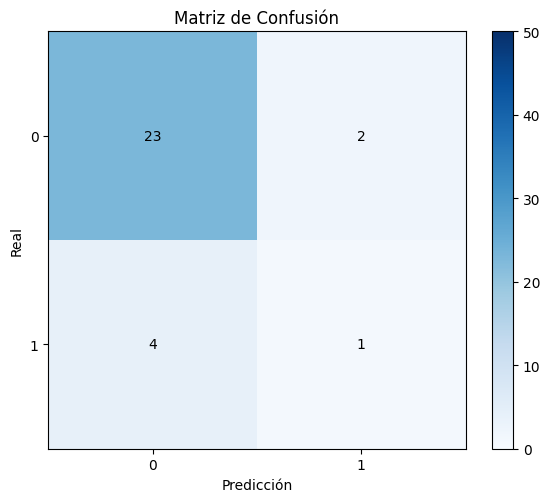

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Definir la matriz de confusión
cm = np.array([[23, 2],
               [4, 1]])
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

# Clases
classes = [0, 1]

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues, vmin=0, vmax=50)
plt.title("Matriz de Confusión")
plt.colorbar()

# Etiquetas de los ejes
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

# Agregar valores dentro de cada celda
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, f"{cm[i, j]:d}",
                 ha="center", va="center", color="black")

plt.ylabel("Real")
plt.xlabel("Predicción")
plt.tight_layout()
plt.show()


In [47]:
from sklearn.preprocessing import LabelEncoder
from models.TIFD import gen_TFID_vectors
#from utils.dataset import gen_dataset
import numpy as np

#Lectura de codigos 
codes_test = dataset_index["Test"]
X_test, y_test, df_test= gen_dataset(codes_test, df)

#Lectura de codigos 
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset(codes_train, df)
df_decode = df_train[["idx", "Código VRID"]]

# Codificación de labels
y_train = np.char.strip(y_train)
# Binarizar
y_train = np.where(
    (y_train == "4") | (y_train == "2.4") ,
    1,
    0
).astype(int)
y_test = np.char.strip(y_test)
# Binarizar
y_test = np.where(
    (y_test == "4") | (y_test == "2.4") ,
    1,
    0
).astype(int)
#Creacion de vectores TFID
X_train, X_test = gen_TFID_vectors(X_train, X_test)
print(X_train.shape, X_test.shape)

(120, 8287) (30, 8287)


In [48]:
from collections import Counter
print("Train label distribution:", Counter(y_train))
print("Test label distribution:", Counter(y_test))

Train label distribution: Counter({0: 89, 1: 31})
Test label distribution: Counter({0: 25, 1: 5})


In [49]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring='f1_macro'
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({0: 89, 1: 31})
📊 test: Counter({0: 25, 1: 5})
(80,)
LogisticRegression
Compute sw


/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [10, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', 'lbfgs'] before, using random point [1.0, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', 'lbfgs'] before, using random point [0.1, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', 'lbfgs'] before, using random point [10, 'l2', 'lbfgs']
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [1.0, 'l2', '

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.46, 'std_test_score': 0.04}
RandomForestClassifier: {'mean_test_score': 0.52, 'std_test_score': 0.02}
XGBClassifier: {'mean_test_score': 0.63, 'std_test_score': 0.09}
SVC: {'mean_test_score': 0.48, 'std_test_score': 0.13}


In [50]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, X_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6, 'f1_macro': 0.44099378881987583, 'cm': array([[17,  8],
       [ 4,  1]]), 'f1_es': 0.6627450980392157, 'f1_en': 0.47692307692307695, 'cm_es': array([[13,  0],
       [ 4,  0]]), 'cm_en': array([[4, 8],
       [0, 1]]), 'precision': 0.1111111111111111, 'recall': 0.2}
RandomForestClassifier
{'accuracy': 0.8, 'f1_macro': 0.5673076923076923, 'cm': array([[23,  2],
       [ 4,  1]]), 'f1_es': 0.6627450980392157, 'f1_en': 0.8776223776223776, 'cm_es': array([[13,  0],
       [ 4,  0]]), 'cm_en': array([[10,  2],
       [ 0,  1]]), 'precision': 0.3333333333333333, 'recall': 0.2}
XGBClassifier
{'accuracy': 0.7333333333333333, 'f1_macro': 0.4230769230769231, 'cm': array([[22,  3],
       [ 5,  0]]), 'f1_es': 0.6627450980392157, 'f1_en': 0.7552447552447552, 'cm_es': array([[13,  0],
       [ 4,  0]]), 'cm_en': array([[9, 3],
       [1, 0]]), 'precision': 0.0, 'recall': 0.0}
SVC
{'accuracy': 0.8, 'f1_macro': 0.4444444444444445, 'cm': array([[24,  1],
       [ 

## Save

In [51]:
exp_info = {
    'exp_name': "Bayesiansearchcv_TFID_desafio_corregido",
    #'artifact_path': "file:///tmp/mlflow_experiments/mlruns", 
    #'tracking_path': "sqlite:////tmp/mlflow_experiments/mlflow.db",
}

extra_parms = {
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring,
    "desafio_label": ["4", "2.4"]
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, extra_parms, X_test, y_test, lang_es)

Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/09/11 20:53:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/14/runs/9e25fb57cec54f10994203de74621c8b
🧪 View experiment at: http://mlflow-server:5000/#/experiments/14
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/09/11 20:54:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/14/runs/7201946c071e48a497d65ce5b77a6858
🧪 View experiment at: http://mlflow-server:5000/#/experiments/14
📝 Registrando modelo en MLflow: XGBClassifier


2025/09/11 20:54:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/14/runs/71112760c37d46f6a1184eeaf98b9f38
🧪 View experiment at: http://mlflow-server:5000/#/experiments/14
📝 Registrando modelo en MLflow: SVC


2025/09/11 20:54:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/14/runs/7ca1bae3350b480097ff1c9fd827f9a3
🧪 View experiment at: http://mlflow-server:5000/#/experiments/14


# 5) SPECTER model

## Train

In [3]:
#Lectura de index de separacion de conjuntos train/test
path = "/tmp/data"
filepath=os.path.join(path, "train_test_ids_3folds.json")
with open(filepath, "r", encoding="utf-8") as f:
    dataset_index = json.load(f)

#Lectura de data
path = "/tmp/data"
filepath=os.path.join(path, "data_translated_concat.csv")
df = pd.read_csv(filepath)

In [4]:
#del gen_dataset
from utils.dataset import gen_dataset
from models.specter import embed_texts
import numpy as np
from sklearn.preprocessing import LabelEncoder

#Lectura de codigos 
codes_test = dataset_index["Test"]
X_test, y_test, df_test= gen_dataset(codes_test, df)

#Lectura de codigos 
codes_train = dataset_index["kfolds"]
codes_train = np.array([i for fold in codes_train for i in fold])
X_train, y_train, df_train = gen_dataset(codes_train, df)
df_decode = df_train[["idx", "Código VRID"]]

# Codificación de labels
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

# 2) Calcular embeddings
# Parámetros modelo
BASE_MODEL = "allenai/specter2_base"
#ADAPTER_NAME = "allenai/specter2"
ADAPTER_NAME="allenai/specter2_classification"
X_train = embed_texts(X_train, BASE_MODEL, ADAPTER_NAME)
X_test = embed_texts(X_test, BASE_MODEL, ADAPTER_NAME)

print(X_train.shape, X_test.shape)

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:830: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


Modelo SPECTER2 cargado correctamente.
(771, 768) (193, 768)


In [5]:
from pipelines.ML_pipeline_skp import get_est_params_dict, run_bayesian_pipeline, select_best_model, eval_model, mlflow_ckeckpoint
from utils.dataset import CvCustom
from collections import Counter

# 2. Elegir modelos a probar
model_keys = [
    'LogisticRegression',
    #'DecisionTreeClassifier',
    'RandomForestClassifier',
    #'GradientBoostingClassifier',
    'XGBClassifier',
    #'MLPClassifier',
    'SVC',
    #'SGDClassifier'
]

# 3. Obtener el diccionario de modelos y parámetros
est_params_dict = get_est_params_dict(model_keys)

print("📊 train:", Counter(y_train))
print("📊 test:", Counter(y_test))
# 4. Ejecutar entrenamiento, validación y test con tus funciones
n_iter=20
sample_weight_On=True
scoring="f1_macro"
results_val, models_dicc = run_bayesian_pipeline(est_params_dict, X_train, y_train, scoring=scoring, cv_function=CvCustom(df_decode), 
                                                 n_iter=n_iter, sample_weight_On = sample_weight_On)

best_model = select_best_model(results_val, models_dicc)

# 5. Mostrar resultados
print("\n🔍 Validación:")
for model, metrics in results_val.items():
    print(f"{model}: {metrics}")

📊 train: Counter({1: 444, 0: 327})
📊 test: Counter({1: 111, 0: 82})
(771,)
LogisticRegression
Compute sw


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

RandomForestClassifier
Compute sw
XGBClassifier
Compute sw
SVC
Compute sw

🔍 Validación:
LogisticRegression: {'mean_test_score': 0.64, 'std_test_score': 0.01}
RandomForestClassifier: {'mean_test_score': 0.63, 'std_test_score': 0.01}
XGBClassifier: {'mean_test_score': 0.62, 'std_test_score': 0.02}
SVC: {'mean_test_score': 0.63, 'std_test_score': 0.01}


In [6]:
# Métricas por idioma
lang_es = df_test["Español"]
for name, model in models_dicc.items():
    print(name)
    results=eval_model(model, X_test, y_test, lang_es)
    print(results)

LogisticRegression
{'accuracy': 0.6476683937823834, 'precision': 0.7087378640776699, 'recall': 0.6576576576576577, 'f1_macro': 0.6434470767224516, 'cm': array([[52, 30],
       [38, 73]]), 'f1_es': 0.6325030804435839, 'f1_en': 0.6575154426904598, 'cm_es': array([[18, 22],
       [20, 55]]), 'cm_en': array([[34,  8],
       [18, 18]])}
RandomForestClassifier
{'accuracy': 0.6683937823834197, 'precision': 0.7079646017699115, 'recall': 0.7207207207207207, 'f1_macro': 0.6596119929453264, 'cm': array([[49, 33],
       [31, 80]]), 'f1_es': 0.6373445535296867, 'f1_en': 0.7038019451812555, 'cm_es': array([[17, 23],
       [18, 57]]), 'cm_en': array([[32, 10],
       [13, 23]])}
XGBClassifier
{'accuracy': 0.6839378238341969, 'precision': 0.7049180327868853, 'recall': 0.7747747747747747, 'f1_macro': 0.6697523072175937, 'cm': array([[46, 36],
       [25, 86]]), 'f1_es': 0.6669747772937873, 'f1_en': 0.6927133512499366, 'cm_es': array([[17, 23],
       [14, 61]]), 'cm_en': array([[29, 13],
       [1

## Save

In [ ]:
exp_info = {
    'exp_name': "Bayesiansearchcv_specter_f1m",
    #'artifact_path': "file:///tmp/mlflow_experiments/mlruns", 
    #'tracking_path': "sqlite:////tmp/mlflow_experiments/mlflow.db",
}

extra_parms = {
    "n_iter": n_iter,
    "sample_weight_On": sample_weight_On,
    "scoring": scoring
}

mlflow_ckeckpoint(exp_info, results_val, models_dicc, extra_parms, X_test, y_test, lang_es)

Current tracking uri: http://mlflow-server:5000
📝 Registrando modelo en MLflow: LogisticRegression


2025/08/29 20:00:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run LogisticRegression at: http://mlflow-server:5000/#/experiments/1/runs/59d9bf17d81740c9808412615b4f1223
🧪 View experiment at: http://mlflow-server:5000/#/experiments/1
📝 Registrando modelo en MLflow: RandomForestClassifier


2025/08/29 20:00:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomForestClassifier at: http://mlflow-server:5000/#/experiments/1/runs/43ab81c635d84877871f6c191ab03d9d
🧪 View experiment at: http://mlflow-server:5000/#/experiments/1
📝 Registrando modelo en MLflow: XGBClassifier


2025/08/29 20:00:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGBClassifier at: http://mlflow-server:5000/#/experiments/1/runs/3b4c012864f34c639fdfa554a4fce910
🧪 View experiment at: http://mlflow-server:5000/#/experiments/1
📝 Registrando modelo en MLflow: SVC


2025/08/29 20:00:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run SVC at: http://mlflow-server:5000/#/experiments/1/runs/a4ecef4973ba4ca0bb6d6fa338bb7e92
🧪 View experiment at: http://mlflow-server:5000/#/experiments/1
